In [ ]:
# Import libraries
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 1. Load dataset from sklearn
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)

# We will use one feature (like temperature proxy)
values = df['MedInc'].values.reshape(-1, 1)  # treat as "weather signal"

# 2. Normalize data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(values)

# 3. Create time-series sequences
def create_sequences(data, time_step=10):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step])
        y.append(data[i+time_step])
    return np.array(X), np.array(y)

time_step = 10
X, y = create_sequences(scaled_data, time_step)

# 4. Train-test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 5. Build LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=False, input_shape=(time_step, 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

# 6. Train model
model.fit(X_train, y_train, epochs=10, batch_size=32)

# 7. Predict
predictions = model.predict(X_test)

# 8. Inverse transform to original scale
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

# 9. Print sample results
for i in range(10):
    print(f"Actual: {y_test_actual[i][0]:.3f}, Predicted: {predictions[i][0]:.3f}")

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0097
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0087
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0086
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0086
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0086
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0086
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0086
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0086
Epoch 9/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0086
Epoch 10/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0086
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Actual: 2.119, Predicted: 3.366
Actual: 2.125, Predicted: 2.858
Actual: 2.995, Predicted: 2.650
Actual: 2.744, Predicted: 2.874
Actual: 2.179, Predicted: 2.826
Actual: 1.485, Predicted: 2.583
Actual: 1.672, Predicted: 2.197
Actual: 2.605, Predicted: 2.092
Actual: 5.193, Predicted: 2.380
Actual: 3.7

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0039
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0030
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0030
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0030
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0030
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0030
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0030
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0030
Epoch 9/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0030
Epoch 10/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0030
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


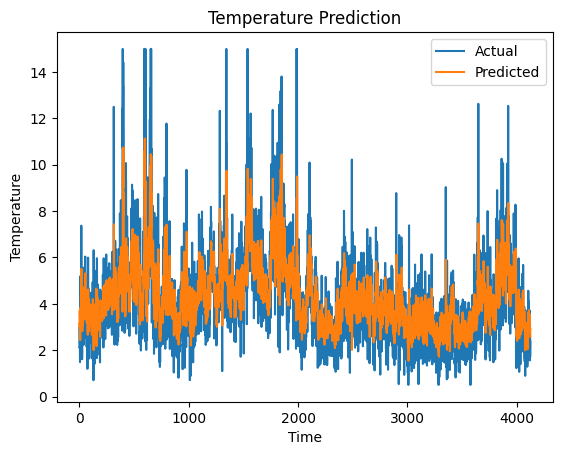

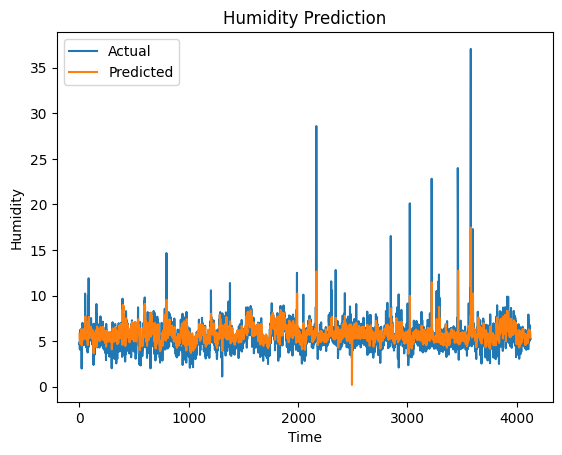

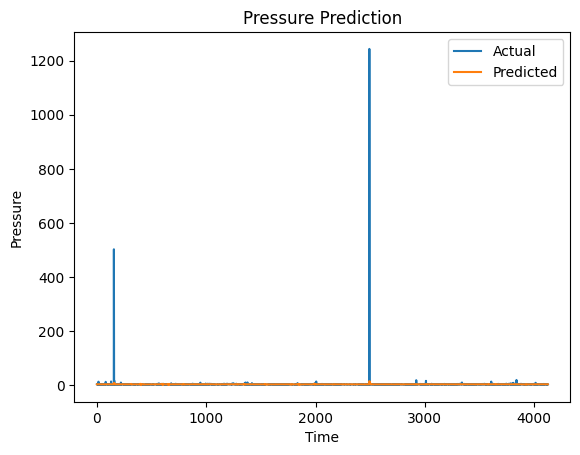


Sample 1
Actual: [2.1186     4.70758123 3.10288809]
Predicted: [3.6678119 5.8010936 3.1777308]

Sample 2
Actual: [2.125      4.91943128 2.46919431]
Predicted: [3.1743739 5.3409314 3.256543 ]

Sample 3
Actual: [2.995      4.75098814 3.0256917 ]
Predicted: [2.9773471 5.230047  3.2882273]

Sample 4
Actual: [2.7443     4.11176471 2.70588235]
Predicted: [3.188553 5.214278 3.242513]

Sample 5
Actual: [2.1786     4.10958904 2.19178082]
Predicted: [3.136131  4.9610996 3.239998 ]


In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 1. Load dataset from sklearn
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)

# Select 3 features as "weather"
# MedInc → temperature
# AveRooms → humidity
# AveOccup → pressure
features = df[['MedInc', 'AveRooms', 'AveOccup']].values

# 2. Normalize
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(features)

# 3. Create sequences
def create_sequences(data, time_step=10):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step])
        y.append(data[i+time_step])  # predict all 3 features
    return np.array(X), np.array(y)

time_step = 10
X, y = create_sequences(scaled_data, time_step)

# 4. Train-test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 5. Build LSTM model
model = Sequential()
model.add(LSTM(64, return_sequences=False, input_shape=(time_step, 3)))
model.add(Dense(3))  # output 3 features

model.compile(optimizer='adam', loss='mean_squared_error')

# 6. Train
model.fit(X_train, y_train, epochs=10, batch_size=32)

# 7. Predict
predictions = model.predict(X_test)

# 8. Inverse transform
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

# 9. Plot results (Temperature, Humidity, Pressure)
labels = ['Temperature', 'Humidity', 'Pressure']

for i in range(3):
    plt.figure()
    plt.plot(y_test_actual[:, i], label='Actual')
    plt.plot(predictions[:, i], label='Predicted')
    plt.title(f"{labels[i]} Prediction")
    plt.xlabel("Time")
    plt.ylabel(labels[i])
    plt.legend()
    plt.show()

# 10. Print sample output
for i in range(5):
    print(f"\nSample {i+1}")
    print("Actual:", y_test_actual[i])
    print("Predicted:", predictions[i])